In [1]:
# ========================================
# Importing Libraries

import pandas as pd # for handling data (tables)
import matplotlib.pyplot as plt # for basic plotting
import seaborn as sns # for advanced plotting

from sklearn.model_selection import train_test_split  # to split data
from sklearn.preprocessing import StandardScaler # to normalize data
from sklearn.linear_model import LogisticRegression # ML model
from sklearn.metrics import accuracy_score  # to check performance

# =====================================================
# TASK 1: DATA EXPLORATION (UNDERSTANDING THE DATA)
# =====================================================

# Loading Data
# USING GIVEN DATA THAT WE PASTED IN CSV FILE
df = pd.read_csv("students.csv")
df.columns = df.columns.str.strip()

# Step 1: Showing First 5 Rows
print("First 5 rows: ")
print(df.head())

# Step 2: Shape and Data Types
print("\nDataset Shape", df.shape)
print("\nData Types: ")
print(df.dtypes)

# Step 3: Summary Statisttics
print("\nSummary Statistics: ")
print(df.describe())

# Step 4: Count Pass VS Fail
print("\nPass vs Fail Count: ")
print(df['passed'].value_counts())

# Step 5: Average Subject Scores (Pass vs Fail)
subject_cols = ['math', 'science', 'english', 'history', 'pe']

print("\nAverage Scores (Passing Students): ")
print(df[df['passed'] == 1][subject_cols].mean())

print("\nAverage Scores (Failing Students): ")
print(df[df['passed'] == 0][subject_cols].mean())# Step 4: Count Pass VS Fail
print("\nPass vs Fail Count: ")
print(df['passed'].value_counts())

# Step 5: Average Subject Scores (Pass vs Fail)
subject_cols = ['math', 'science', 'english', 'history', 'pe']

print("\nAverage Scores (Passing Students): ")
print(df[df['passed'] == 1][subject_cols].mean())

print("\nAverage Scores (Failing Students): ")
print(df[df['passed'] == 0][subject_cols].mean())

# Step 6: Finding Best Student 
df['overall_avg'] = df[subject_cols].mean(axis=1)

best_student = df.loc[df['overall_avg'].idxmax()]
print("\nTop Student: ")
print(best_student[['name', 'overall_avg']])

First 5 rows: 
      name  math  science  english  history  pe  attendance_pct  \
0    Alice    88       92       76       80  95              92   
1      Bob    42       55       48       50  60              65   
2  Charlie    75       70       80       68  88              85   
3    Diana    95       98       91       89  97              98   
4      Eve    38       42       50       45  55              58   

   study_hours_per_day  passed  
0                  4.5       1  
1                  1.2       0  
2                  3.0       1  
3                  6.0       1  
4                  0.8       0  

Dataset Shape (15, 9)

Data Types: 
name                       str
math                     int64
science                  int64
english                  int64
history                  int64
pe                       int64
attendance_pct           int64
study_hours_per_day    float64
passed                   int64
dtype: object

Summary Statistics: 
            math    science    e

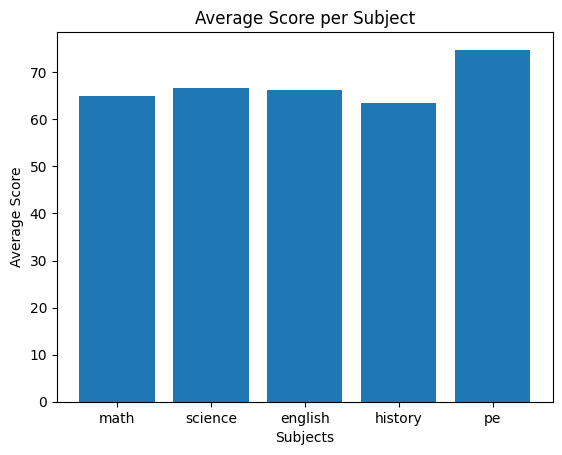

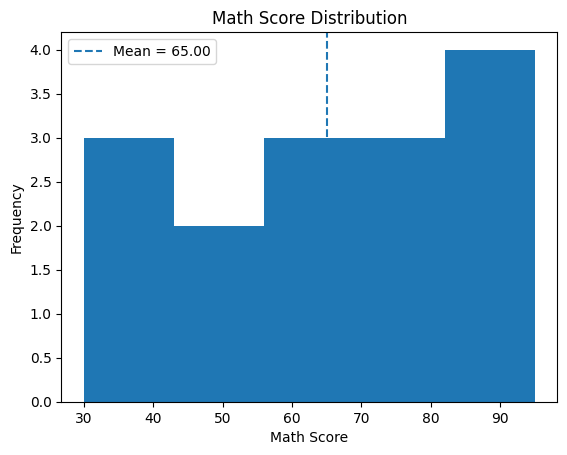

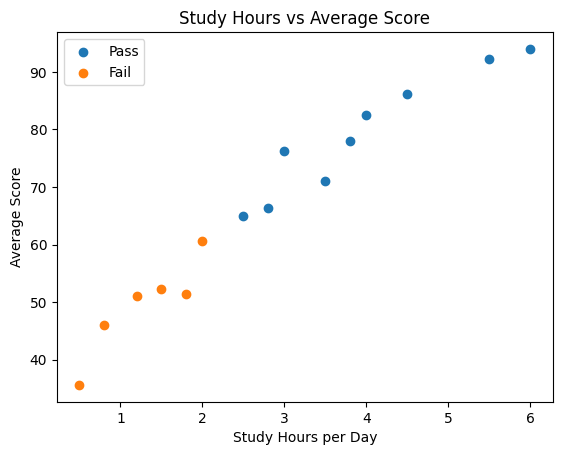

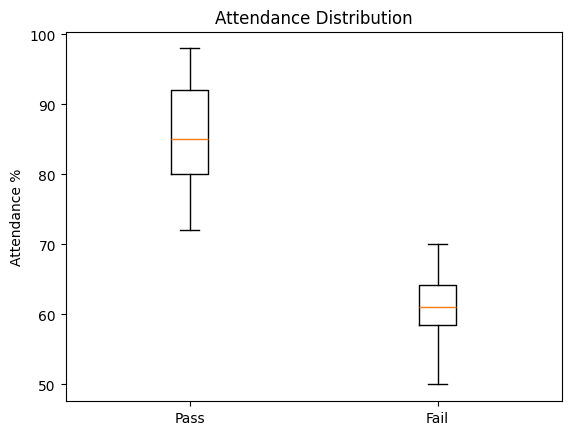

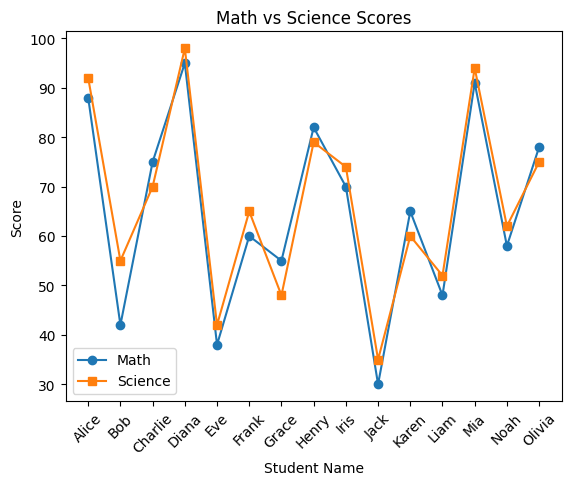

In [2]:
# =====================================================
# TASK 2: MATPLOTLIB VISUALIZATION
# =====================================================

subject_cols = ['math', 'science', 'english', 'history', 'pe']
df['avg_score'] = df[subject_cols].mean(axis=1)

# Step 1: Plotting - Bar Chart
plt.figure()

avg_scores = df[subject_cols].mean()
plt.bar(subject_cols, avg_scores)

plt.title("Average Score per Subject")
plt.xlabel("Subjects")
plt.ylabel("Average Score")

plt.savefig("plot1_bar.png")
plt.show()

# STEP 2: Plotting - HISTOGRAM 
plt.figure()

plt.hist(df['math'], bins=5)
mean_math = df['math'].mean()
plt.axvline(mean_math, linestyle='dashed', label=f"Mean = {mean_math:.2f}")

plt.title("Math Score Distribution")
plt.xlabel("Math Score")
plt.ylabel("Frequency")
plt.legend()

plt.savefig("plot2_hist.png")
plt.show()

# STEP 3: SCATTER PLOT
plt.figure()

pass_df = df[df['passed'] == 1]
fail_df = df[df['passed'] == 0]

plt.scatter(pass_df['study_hours_per_day'], pass_df['avg_score'], label='Pass')
plt.scatter(fail_df['study_hours_per_day'], fail_df['avg_score'], label='Fail')

plt.title("Study Hours vs Average Score")
plt.xlabel("Study Hours per Day")
plt.ylabel("Average Score")
plt.legend()

plt.savefig("plot3_scatter.png")
plt.show()

# STEP 4: BOX PLOT
plt.figure()

pass_attendance = pass_df['attendance_pct'].tolist()
fail_attendance = fail_df['attendance_pct'].tolist()

plt.boxplot([pass_attendance, fail_attendance], tick_labels=['Pass', 'Fail'])

plt.title("Attendance Distribution")
plt.ylabel("Attendance %")

plt.savefig("plot4_box.png")
plt.show()

# STEP 5: LINE PLOT 
plt.figure()

plt.plot(df['name'], df['math'], marker='o', label='Math')
plt.plot(df['name'], df['science'], marker='s', label='Science')

plt.xticks(rotation=45)
plt.title("Math vs Science Scores")
plt.xlabel("Student Name")
plt.ylabel("Score")
plt.legend()

plt.savefig("plot5_line.png")
plt.show()


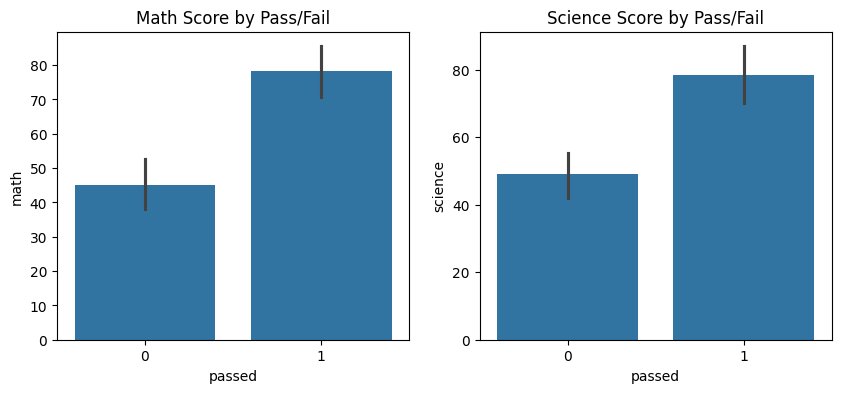

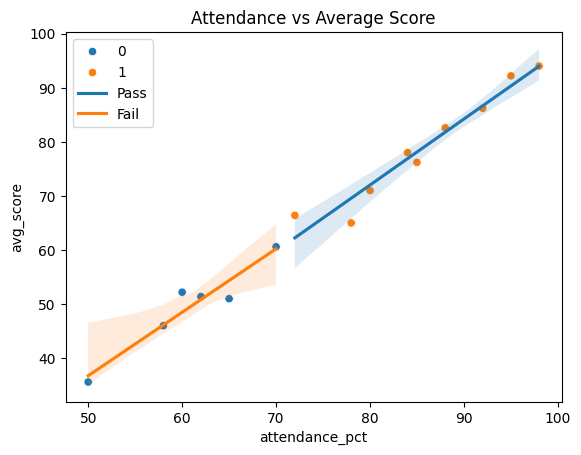

In [3]:
# ========================================
# TASK 3
# ========================================

# Plotting: Seaborn BAR PLOT (plot 6)
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.barplot(data=df, x='passed', y='math')
plt.title("Math Score by Pass/Fail")

plt.subplot(1,2,2)
sns.barplot(data=df, x='passed', y='science')
plt.title("Science Score by Pass/Fail")

plt.savefig("plot6_seaborn_bar.png")
plt.show()

# Plotting: Seaborn Satter + Regression (plot 7)
plt.figure()

sns.scatterplot(data=df, x='attendance_pct', y='avg_score', hue='passed')

sns.regplot(data=df[df['passed']==1], x='attendance_pct', y='avg_score', scatter=False, label='Pass')
sns.regplot(data=df[df['passed']==0], x='attendance_pct', y='avg_score', scatter=False, label='Fail')

plt.title("Attendance vs Average Score")
plt.legend()

plt.savefig("plot7_seaborn_scatter.png")
plt.show()

Training Accuracy:  1.0
Test Accuracy: 1.0

Predictions:
Jack: Actual=0, Predicted=0 ✅
Liam: Actual=0, Predicted=0 ✅
Alice: Actual=1, Predicted=1 ✅

Feature Importance: 
english: 0.8125
attendance_pct: 0.5219
study_hours_per_day: 0.4844
pe: 0.4750
math: 0.4379
science: 0.3230
history: 0.2629


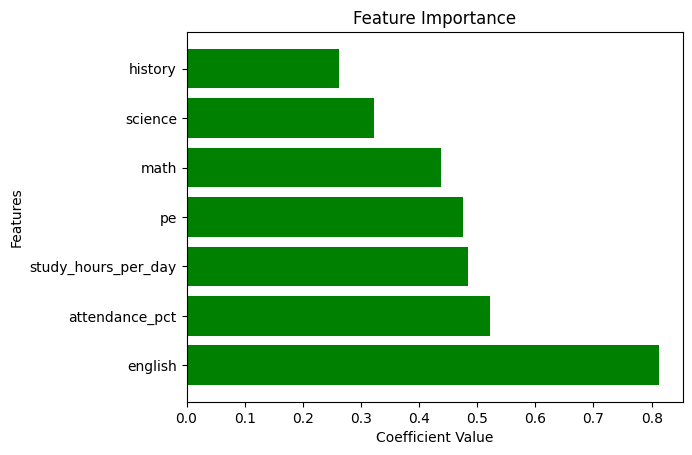


New Student Prediction:
Prediction: Pass
Probability: [0.09203526 0.90796474]


In [4]:
# ========================================
# TASK 4 (ML)
# ========================================

# STEP 1: Preparing Data
features = ['math','science','english','history','pe','attendance_pct','study_hours_per_day']

X = df[features]
y = df['passed']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scaling Data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# STEP 2: Training Model
model = LogisticRegression()
model.fit(X_train_scaled, y_train)

print("Training Accuracy: ", model.score(X_train_scaled, y_train))

# STEP 3: Evaulating Model
y_pred = model.predict(X_test_scaled)

print("Test Accuracy:", accuracy_score(y_test, y_pred))

print("\nPredictions:")

names = df.loc[X_test.index, 'name']

for name, actual, pred in zip(names, y_test, y_pred):
    result = "✅" if actual == pred else "❌"
    print(f"{name}: Actual={actual}, Predicted={pred} {result}")

# STEP 4: Featuring Importance 
coeffs = model.coef_[0]

importance = list(zip(features, coeffs))
importance.sort(key=lambda x: abs(x[1]), reverse=True)

print("\nFeature Importance: ")
for f, c in importance:
    print(f"{f}: {c:.4f}")

# Plot Feature Importance
plt.figure()

features_sorted = [f for f, c in importance]
coeffs_sorted = [c for f, c in importance]

colors = ['green' if c > 0 else 'red' for c in coeffs_sorted]

plt.barh(features_sorted, coeffs_sorted, color=colors)
plt.title("Feature Importance")
plt.xlabel("Coefficient Value")
plt.ylabel("Features")

plt.show()

# STEP 5: New Student Prediction
new_student = pd.DataFrame(
    [[75, 70, 68, 65, 80, 82, 3.2]],  # order must match feature columns
    columns=features
)

scaled_new = scaler.transform(new_student)

prediction = model.predict(scaled_new)[0]
probability = model.predict_proba(scaled_new)[0]

print("\nNew Student Prediction:")
print("Prediction:", "Pass" if prediction == 1 else "Fail")
print("Probability:", probability)